In [1]:
# magic command not supported in marimo; please file an issue to add support
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from tqdm.auto import tqdm

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
)
from JacobianODE.fnn import loss_amplification, loss_false
from JacobianODE.jacobians.data import embed_signal_torch

In [3]:
# ----------------------------------------------------------------
# Data source: "dysts" or "wmtask"
# ----------------------------------------------------------------
DATA_SOURCE = "dysts"   # <-- change to "wmtask" for WM task RNN data
# DATA_SOURCE = "wmtask"

# ----------------------------------------------------------------
# wmtask-specific hyperparameters (ignored when DATA_SOURCE="dysts")
# ----------------------------------------------------------------
WMTASK_PROJECT = "WMSelectionTask__cue_time_0.1__response_time_0.25__enforce_fixation_False"
WMTASK_NAME = "BiologicalRNN__cue_time_0.1__learning_rate_0.0005__max_epochs_42__N1_64__N2_64__tau_0.05__dt_0.02__eig_lower_bound_0.1__init_mode_random"
WMTASK_MODEL_TO_LOAD = "final"
WMTASK_DATALOADER = "all"
WMTASK_TRAJ_WINDOW = "delay2"
WMTASK_DIM = 128  # N1 + N2 = 64 + 64

# For wmtask: which dimensions to use for delay embedding.
# "all" = use full 128-dim hidden state; or a list of indices, e.g. [0], [0, 1, 2], or list(range(42))
# WMTASK_OBSERVED_INDICES = "all"
USE_PARTIAL_OBS = True
# N_PARTIAL_OBS = 42
N_PARTIAL_OBS = 12
PARTIAL_OBS_SEED = 42
if USE_PARTIAL_OBS:
    np.random.seed(PARTIAL_OBS_SEED)
    WMTASK_OBSERVED_INDICES = sorted(np.random.choice(WMTASK_DIM, N_PARTIAL_OBS, replace=False).tolist())
else:
    WMTASK_OBSERVED_INDICES = "all"

In [ ]:
# Build config overrides based on DATA_SOURCE
OBS_NOISE = 0.05
overrides = [
    f"data={DATA_SOURCE}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    f"training.logger.save_dir={os.getcwd()}",
]
if DATA_SOURCE == "wmtask":
    overrides.extend([
        f"++data.dataset_loader.project={WMTASK_PROJECT}",
        f"++data.dataset_loader.name={WMTASK_NAME}",
        f"++data.dataset_loader.model_to_load={WMTASK_MODEL_TO_LOAD}",
        f"++data.dataset_loader.dataloader_to_use={WMTASK_DATALOADER}",
        f"++data.dataset_loader.traj_window={WMTASK_TRAJ_WINDOW}",
        f"++data.flow.dim={WMTASK_DIM}",
        "data.postprocessing.normalize=true",
    ])
cfg = load_config(overrides=overrides)
cfg = initialize_config(cfg)
seed_everything(cfg.data.flow.random_state + cfg.training.run_number)

eq, sol, dt = make_trajectories(cfg, verbose=True)
values_raw = sol["values"]  # shape (n_trials, n_timepoints, n_dims)
result = postprocess_data(cfg, values_raw)
values = result.values
print(f"Loaded {DATA_SOURCE}: {values.shape}, dt={dt:.4f}")

# x: observed dimensions for delay embedding. x_full: full state for conformal variance.
if DATA_SOURCE == "dysts":
    x = torch.from_numpy(values)[..., [0]]
else:
    if WMTASK_OBSERVED_INDICES == "all":
        x = torch.from_numpy(values)
    else:
        x = torch.from_numpy(values)[..., WMTASK_OBSERVED_INDICES]
print(f"x (for delay embedding): {x.shape}")

Loaded dysts: (32, 1200, 3), dt=0.0150
x (for delay embedding): torch.Size([32, 1200, 1])


In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
amplification_losses = {}
fnn_losses = {}
fnn_weights_avg = {}

def compute_fnn_metric(x_prev: torch.Tensor, x_test: torch.Tensor, k: int=10, rtol: float=20.0, atol: float=2.0, n_samples: int=None) -> float:
    """
    Computes the percentage of False Nearest Neighbors of x_prev when embedded into x_test.
    Exactly matches the Kennel et al. math used in loss_false.

    Parameters
    ----------
    x_prev : torch.Tensor
        (batch_size, D_prev) tensor of the base embedding.
    x_test : torch.Tensor
        (batch_size, D_test) tensor of the higher-dimensional embedding.
    k : int
        Number of nearest neighbors to evaluate.
    rtol : float
        Relative tolerance threshold for distance expansion.
    atol : float
        Absolute tolerance threshold for distance expansion.
    n_samples : int or None
        Optional random subsampling to prevent O(N^2) memory explosion.

    Returns
    -------
    float
        The fraction of false nearest neighbors (0.0 to 1.0).
    """
    if n_samples is not None and len(x_prev) > n_samples:
        idx = torch.randperm(len(x_prev), device=x_prev.device)[:n_samples]
        x_prev = x_prev[idx]
        x_test = x_test[idx]
    x_prev_sq = (x_prev * x_prev).sum(dim=1, keepdim=True)
    dist_prev = x_prev_sq + x_prev_sq.T - 2 * torch.mm(x_prev, x_prev.T)
    dist_prev = torch.clamp(dist_prev, min=1e-14)
    x_test_sq = (x_test * x_test).sum(dim=1, keepdim=True)
    dist_test = x_test_sq + x_test_sq.T - 2 * torch.mm(x_test, x_test.T)
    dist_test = torch.clamp(dist_test, min=1e-14)
    ra_squared = torch.mean(torch.std(x_prev, dim=0) ** 2)
    _, inds = torch.topk(-dist_prev, k + 1, dim=-1)
    neighbor_dists_prev = torch.gather(dist_prev, 1, inds)
    neighbor_dists_test = torch.gather(dist_test, 1, inds)
    scaled_dist_squared = torch.clamp((neighbor_dists_test - neighbor_dists_prev) / neighbor_dists_prev, min=0.0)
    is_false_change = scaled_dist_squared > rtol ** 2
    is_large_jump = neighbor_dists_test > atol ** 2 * ra_squared
    is_false_neighbor = is_false_change | is_large_jump
    total_false_neighbors = is_false_neighbor[:, 1:k + 1]
    return total_false_neighbors.float().mean().item()
AMP_N_NEIGHBORS = 10
if DATA_SOURCE == 'wmtask':
    N_DELAYS_VALS = np.arange(1, 16)
    INTERVAL_VALS = [1]
    MAX_T = 10
else:
    N_DELAYS_VALS = np.arange(1, 101)
    INTERVAL_VALS = [1]
    MAX_T = 30
iterator = tqdm(total=len(N_DELAYS_VALS) * len(INTERVAL_VALS))
x_prev = None
for _n_delays in N_DELAYS_VALS:
    for _delay_interval in INTERVAL_VALS:
        if x.shape[1] - (_n_delays - 1) * _delay_interval <= 0:
            print(f'Skipping n_delays={_n_delays}, delay_interval={_delay_interval} because x.shape[1] - (n_delays - 1) * delay_interval <= 0')
            iterator.update(1)
            continue
        x_embedded = embed_signal_torch(x, _n_delays, _delay_interval)
        x_embedded = x_embedded.to(device)
        x_data = x_embedded[..., :x.shape[-1]]
        if x_embedded.shape[1] < x.shape[1] * 0.5:
            print(f'Skipping n_delays={_n_delays}, delay_interval={_delay_interval} because x_embedded.shape[1] < x.shape[1]*(0.5)')
            iterator.update(1)
            continue
        _loss = loss_amplification(
            x_embedded,
            x_data.to(device),
            max_T=MAX_T,
            n_neighbors=AMP_N_NEIGHBORS,
            normalize=True,
        )
        amplification_losses[_n_delays, _delay_interval] = _loss.item()
        obs_dim = x.shape[-1]
        x_test_flat = x_embedded.reshape(-1, x_embedded.shape[-1])
        if _n_delays == 1:
            fnn_losses[_n_delays, _delay_interval] = 1.0
        else:
            x_prev_flat = x_test_flat[:, obs_dim:]
            fnn_losses[_n_delays, _delay_interval] = compute_fnn_metric(x_prev=x_prev_flat, x_test=x_test_flat, k=10, n_samples=4096)
        iterator.update(1)
iterator.close()

  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_505946/2750352815.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis').copy()


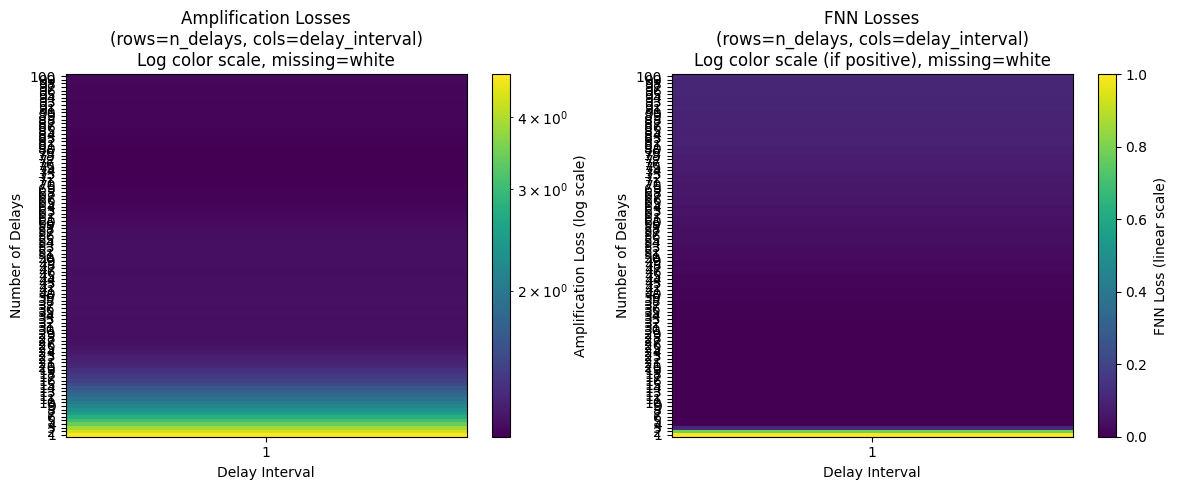

In [9]:
from matplotlib.colors import LogNorm
n_delays_max = max(N_DELAYS_VALS)
_interval_max = max(INTERVAL_VALS)
amplification_loss_matrix = np.full((n_delays_max, _interval_max), np.nan)
fnn_loss_matrix = np.full((n_delays_max, _interval_max), np.nan)
for (_n_delays, _delay_interval), _loss in amplification_losses.items():
    amplification_loss_matrix[_n_delays - 1, _delay_interval - 1] = float(_loss)
for (_n_delays, _delay_interval), _loss in fnn_losses.items():
    fnn_loss_matrix[_n_delays - 1, _delay_interval - 1] = float(_loss)
from matplotlib import cm
cmap = cm.get_cmap('viridis').copy()
cmap.set_bad(color='white')
non_nan_amp = np.isfinite(amplification_loss_matrix)
if np.any(non_nan_amp):
    vmin_amp = np.nanmin(amplification_loss_matrix)
    vmax_amp = np.nanmax(amplification_loss_matrix)
else:
    vmin_amp, vmax_amp = (1, 10)
non_nan_fnn = np.isfinite(fnn_loss_matrix)
if np.any(non_nan_fnn):
    vmin_fnn = np.nanmin(fnn_loss_matrix)
    vmax_fnn = np.nanmax(fnn_loss_matrix)
else:
    vmin_fnn, vmax_fnn = (0.01, 1)
fnn_strictly_positive = np.nanmin(fnn_loss_matrix) > 0
norm_fnn = LogNorm(vmin=max(vmin_fnn, 1e-08), vmax=vmax_fnn) if fnn_strictly_positive else None
_fig, _axs = plt.subplots(1, 2, figsize=(12, 5))
im0 = _axs[0].imshow(np.ma.masked_invalid(amplification_loss_matrix), origin='lower', aspect='auto', cmap=cmap, norm=LogNorm(vmin=vmin_amp, vmax=vmax_amp))
cbar0 = plt.colorbar(im0, ax=_axs[0], label='Amplification Loss (log scale)')
im1 = _axs[1].imshow(np.ma.masked_invalid(fnn_loss_matrix), origin='lower', aspect='auto', cmap=cmap, norm=norm_fnn)
if fnn_strictly_positive:
    cbar1 = plt.colorbar(im1, ax=_axs[1], label='FNN Loss (log scale)')
else:
    cbar1 = plt.colorbar(im1, ax=_axs[1], label='FNN Loss (linear scale)')
for ax in _axs:
    ax.set_xticks(np.arange(_interval_max))
    ax.set_yticks(np.arange(n_delays_max))
    ax.set_xticklabels(np.arange(1, _interval_max + 1))
    ax.set_yticklabels(np.arange(1, n_delays_max + 1))
    ax.set_xlabel('Delay Interval')
    ax.set_ylabel('Number of Delays')
_axs[0].set_title('Amplification Losses\n(rows=n_delays, cols=delay_interval)\nLog color scale, missing=white')
_axs[1].set_title('FNN Losses\n(rows=n_delays, cols=delay_interval)\nLog color scale (if positive), missing=white')
plt.tight_layout()
plt.show()

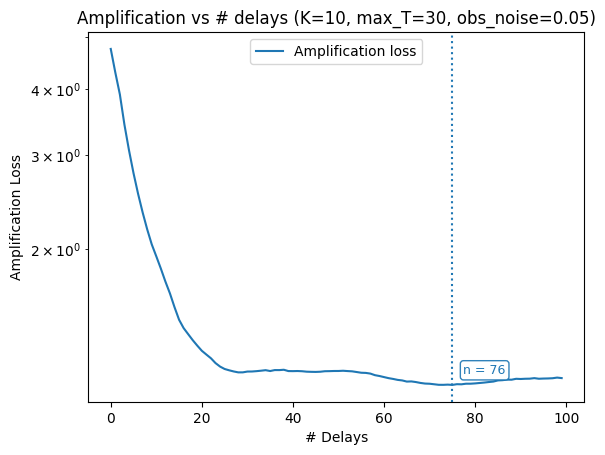

In [10]:
PLOT_FNN_ON_DELAY_CURVES = False
from matplotlib.lines import Line2D

_, ax1 = plt.subplots()
lines1 = ax1.plot(amplification_loss_matrix)
ax1.set_ylabel('Amplification Loss')
ax1.set_xlabel('# Delays')
ax1.set_yscale('log')
if np.any(np.isfinite(amplification_loss_matrix)):
    _idx_amp = np.nanargmin(amplification_loss_matrix)
    _i_amp = int(np.unravel_index(_idx_amp, amplification_loss_matrix.shape)[0])
    _v_amp = float(np.ravel(amplification_loss_matrix)[_idx_amp])
    ax1.axvline(_i_amp, color='tab:blue', linestyle=':', linewidth=1.5, zorder=0)
    ax1.annotate(
        f'n = {_i_amp + 1}',
        xy=(_i_amp, _v_amp),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=9,
        color='tab:blue',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:blue', alpha=0.92),
    )

legend_handles = [
    Line2D([0], [0], color=lines1[0].get_color(), linestyle='-', label='Amplification loss'),
]
if PLOT_FNN_ON_DELAY_CURVES:
    ax2 = ax1.twinx()
    lines2 = ax2.plot(fnn_loss_matrix, c='C1')
    ax2.set_ylabel('FNN Loss')
    legend_handles.append(
        Line2D([0], [0], color=lines2[0].get_color(), linestyle='-', label='FNN loss'),
    )
    if np.any(np.isfinite(fnn_loss_matrix)):
        _i_fnn = int(np.unravel_index(
            np.nanargmin(fnn_loss_matrix),
            fnn_loss_matrix.shape,
        )[0])
        ax2.axvline(_i_fnn, color='tab:orange', linestyle=':', linewidth=1.5, zorder=0)

ax1.set_title(
    f'Amplification vs # delays (K={AMP_N_NEIGHBORS}, max_T={MAX_T}, obs_noise={OBS_NOISE})',
)
ax1.legend(handles=legend_handles, loc='best')
plt.show()

In [ ]:
# Color the scatter plot by delay number (y-axis index) AND by delay interval (x-axis index)
_n_delays, _interval_max = amplification_loss_matrix.shape
_delay_numbers = np.arange(1, _n_delays + 1)
delay_intervals = np.arange(1, _interval_max + 1)  # Rows: y-axis (delay number)
_fig, _axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)  # Cols: x-axis (delay interval)
sc_delaynum = _axs[0].scatter(amplification_loss_matrix.flatten(), fnn_loss_matrix.flatten(), c=np.repeat(_delay_numbers, _interval_max), cmap='viridis', alpha=0.8)
_axs[0].set_xlabel('Amplification Loss')
_axs[0].set_ylabel('FNN Loss')
# LEFT: colored by delay number
_axs[0].set_xscale('log')
_axs[0].set_yscale('log')
plt.colorbar(sc_delaynum, ax=_axs[0], label='Delay Number')
interval_colors = np.tile(delay_intervals, _n_delays)
sc_delayint = _axs[1].scatter(amplification_loss_matrix.flatten(), fnn_loss_matrix.flatten(), c=interval_colors, cmap='plasma', alpha=0.8)
_axs[1].set_xlabel('Amplification Loss')
_axs[1].set_ylabel('FNN Loss')
_axs[1].set_xscale('log')
_axs[1].set_yscale('log')
plt.colorbar(sc_delayint, ax=_axs[1], label='Delay Interval')
_axs[0].set_title('Colored by Delay Number (row in matrix)')
_axs[1].set_title('Colored by Delay Interval (column in matrix)')
# RIGHT: colored by delay interval
# build 2D colors for each point:
plt.show()

In [ ]:
n_delays_list = []
delay_intervals_list = []
fnn_scores = []
amp_scores = []
for key in fnn_losses:
    n_delays_list.append(key[0])
    delay_intervals_list.append(key[1])
    fnn_scores.append(fnn_losses[key])
    amp_scores.append(amplification_losses[key])
fnn_scores = np.array(fnn_scores)
amp_scores = np.array(amp_scores)

In [ ]:
n_delays_list[amp_scores.argmin()], delay_intervals_list[amp_scores.argmin()]

In [ ]:
from scipy.stats import spearmanr

def auto_optimal_delay(fnn_scores, amp_scores):
    fnn = np.array(fnn_scores)
    amp = np.array(amp_scores)
    fnn_norm = (fnn - np.min(fnn)) / (np.max(fnn) - np.min(fnn))
    amp_norm = (amp - np.min(amp)) / (np.max(amp) - np.min(amp))
    print(fnn, amp)
    corr, _ = spearmanr(fnn, amp)  # Normalize to [0, 1] to make the space unitless
    print(f'Spearman Rank Correlation: {corr:.4f}')
    if corr > 0:
        print('Logic: Metrics agree. Using Utopia Point Method.')
        distances = np.sqrt(fnn_norm ** 2 + amp_norm ** 2)  # Calculate Spearman rank correlation
        optimal_idx = np.argmin(distances)
    else:
        print('Logic: Trade-off detected. Using Geometric Chord Method.')
        idx_min_fnn = np.argmin(fnn_norm)
        idx_min_amp = np.argmin(amp_norm)  # ROUTE 1: Metrics Agree (Positive Correlation)
        if idx_min_fnn == idx_min_amp:
            optimal_idx = idx_min_fnn
        else:
            p_A = np.array([fnn_norm[idx_min_fnn], amp_norm[idx_min_fnn]])
            p_B = np.array([fnn_norm[idx_min_amp], amp_norm[idx_min_amp]])
            v = p_B - p_A  # ROUTE 2: Metrics Trade-off (Negative Correlation)
            v_mag = np.linalg.norm(v)
            if v_mag < 1e-08:
                optimal_idx = idx_min_fnn
            else:
                distances = []
                for i in range(len(fnn)):  # Edge Case: Global optimum exists despite negative macro-correlation
                    p_i = np.array([fnn_norm[i], amp_norm[i]])
                    u = p_i - p_A
                    cross_prod = np.abs(v[0] * u[1] - v[1] * u[0])
                    distances.append(cross_prod / v_mag)
                optimal_idx = np.argmax(distances)
    print(f'\nFinal Optimal Delay Index: {optimal_idx}')
    fnn_val = fnn[optimal_idx]
    amp_val = amp[optimal_idx]
    if isinstance(fnn_val, np.ndarray):
        fnn_val = fnn_val.item()
    if isinstance(amp_val, np.ndarray):
        amp_val = amp_val.item()
    print(f'  FNN Score: {fnn_val:.4f}')
    print(f'  Amp Score: {amp_val:.4f}')
    return optimal_idx
optimal_idx = auto_optimal_delay(fnn_scores, amp_scores)
print(f'Optimal Delay Index: {optimal_idx}')  # If the selection from fnn/amp is an ndarray (e.g., from 2D input), take just the scalar value

In [ ]:
# Color the scatter plot by delay number (y-axis index)
_n_delays = amplification_loss_matrix.shape[0]
_delay_numbers = np.arange(1, _n_delays + 1)
colors = _delay_numbers[:, None] * np.ones_like(amplification_loss_matrix)
plt.scatter(amplification_loss_matrix.flatten(), fnn_loss_matrix.flatten(), c=np.repeat(_delay_numbers, amplification_loss_matrix.shape[1]), cmap='viridis', alpha=0.8)
plt.xlabel('Amplification Loss')
plt.ylabel('FNN Loss')
plt.scatter(amplification_loss_matrix[optimal_idx], fnn_loss_matrix[optimal_idx], c='magenta', s=100)
cbar = plt.colorbar(label='Delay Number')
# plt.xscale('log')
plt.show()

In [ ]:
# Find the (n_delays, delay_interval) that gives the minimum amplification loss
best_amp_params = min(amplification_losses, key=amplification_losses.get)
best_amp_n_delays, best_amp_delay_interval = best_amp_params
best_amp_loss = amplification_losses[best_amp_params]

print(f"Best amplification loss: {best_amp_loss:.5g} at n_delays={best_amp_n_delays}, delay_interval={best_amp_delay_interval}")

# Generate the embedding with these optimal parameters for amplification loss
best_amp_x_embedded = embed_signal_torch(x, best_amp_n_delays, best_amp_delay_interval)

# Also find the minimum amplification loss when delay_interval == 1
amp_candidates_delay1 = {k: v for k, v in amplification_losses.items() if k[1] == 1}
if amp_candidates_delay1:
    best_amp_params_delay1 = min(amp_candidates_delay1, key=amp_candidates_delay1.get)
    best_amp_n_delays_delay1, best_amp_delay_interval_delay1 = best_amp_params_delay1
    best_amp_loss_delay1 = amplification_losses[best_amp_params_delay1]
    print(f"Best amplification loss (delay_interval=1): {best_amp_loss_delay1:.5g} at n_delays={best_amp_n_delays_delay1}, delay_interval={best_amp_delay_interval_delay1}")

    # Generate the embedding with these optimal parameters for amplification loss at delay_interval=1
    best_amp_x_embedded_delay1 = embed_signal_torch(x, best_amp_n_delays_delay1, best_amp_delay_interval_delay1)
else:
    print("No amplification losses found with delay_interval=1; skipping best amplification embedding with delay_interval=1.")
    best_amp_x_embedded_delay1 = None

# Find the (n_delays, delay_interval) that gives the minimum FNN loss (excluding n_delays=1)
if len(fnn_losses) > 0:
    # Exclude n_delays == 1 from candidates
    fnn_candidates = {k: v for k, v in fnn_losses.items() if k[0] > 1}
    if fnn_candidates:
        best_fnn_params = min(fnn_candidates, key=fnn_candidates.get)
        best_fnn_n_delays, best_fnn_delay_interval = best_fnn_params
        best_fnn_loss = fnn_losses[best_fnn_params]
        print(f"Best FNN loss (n_delays > 1): {best_fnn_loss:.5g} at n_delays={best_fnn_n_delays}, delay_interval={best_fnn_delay_interval}")

        # Generate the embedding with these optimal parameters for FNN loss
        best_fnn_x_embedded = embed_signal_torch(x, best_fnn_n_delays, best_fnn_delay_interval)
    else:
        print("No FNN losses found with n_delays > 1; skipping best FNN embedding.")
        best_fnn_x_embedded = None
else:
    print("No FNN losses found; skipping best FNN embedding.")
    best_fnn_x_embedded = None

In [ ]:
amp_emb_pca = None
amp_emb_eigvals = None
amp_emb_n99 = None
if 'best_amp_x_embedded' in locals() and best_amp_x_embedded is not None:
    amp_emb_flat = best_amp_x_embedded.reshape(-1, best_amp_x_embedded.shape[-1])
    amp_emb_flat_centered = amp_emb_flat - torch.mean(amp_emb_flat, dim=0, keepdim=True)
    amp_emb_cov = torch.cov(amp_emb_flat_centered.T)
    amp_emb_eigvals, amp_emb_eigvecs = torch.linalg.eigh(amp_emb_cov)
    amp_emb_eigvals = amp_emb_eigvals.flip(dims=(0,))
    amp_emb_eigvecs = amp_emb_eigvecs.flip(dims=(1,))
    amp_emb_pr = amp_emb_eigvals.sum() ** 2 / (amp_emb_eigvals ** 2).sum()
    amp_emb_var_cumsum = torch.cumsum(amp_emb_eigvals, 0) / torch.sum(amp_emb_eigvals)
    amp_emb_n99 = int((amp_emb_var_cumsum < 0.99).sum().item() + 1)
    print(f'Amp Chosen Embedding Participation Ratio: {amp_emb_pr.item():.3f}')
    print(f'Dimensions for 99% var (amplification-optimal): {amp_emb_n99}')
    amp_emb_pca = amp_emb_flat_centered @ amp_emb_eigvecs
amp_emb_pca_delay1 = None
amp_emb_eigvals_delay1 = None
amp_emb_n99_delay1 = None
if 'best_amp_x_embedded_delay1' in locals() and best_amp_x_embedded_delay1 is not None:
    amp_emb_flat_delay1 = best_amp_x_embedded_delay1.reshape(-1, best_amp_x_embedded_delay1.shape[-1])
    amp_emb_flat_centered_delay1 = amp_emb_flat_delay1 - torch.mean(amp_emb_flat_delay1, dim=0, keepdim=True)
    amp_emb_cov_delay1 = torch.cov(amp_emb_flat_centered_delay1.T)
    amp_emb_eigvals_delay1, amp_emb_eigvecs_delay1 = torch.linalg.eigh(amp_emb_cov_delay1)
    amp_emb_eigvals_delay1 = amp_emb_eigvals_delay1.flip(dims=(0,))
    amp_emb_eigvecs_delay1 = amp_emb_eigvecs_delay1.flip(dims=(1,))
    amp_emb_pr_delay1 = amp_emb_eigvals_delay1.sum() ** 2 / (amp_emb_eigvals_delay1 ** 2).sum()
    amp_emb_var_cumsum_delay1 = torch.cumsum(amp_emb_eigvals_delay1, 0) / torch.sum(amp_emb_eigvals_delay1)
    amp_emb_n99_delay1 = int((amp_emb_var_cumsum_delay1 < 0.99).sum().item() + 1)
    print(f'Amp Embedding (delay_interval=1) Participation Ratio: {amp_emb_pr_delay1.item():.3f}')
    print(f'Dimensions for 99% var (amplification, delay=1): {amp_emb_n99_delay1}')
    amp_emb_pca_delay1 = amp_emb_flat_centered_delay1 @ amp_emb_eigvecs_delay1
fnn_emb_pca = None
fnn_emb_eigvals = None
fnn_emb_n99 = None
if 'best_fnn_x_embedded' in locals() and best_fnn_x_embedded is not None:
    fnn_emb_flat = best_fnn_x_embedded.reshape(-1, best_fnn_x_embedded.shape[-1])
    fnn_emb_flat_centered = fnn_emb_flat - torch.mean(fnn_emb_flat, dim=0, keepdim=True)
    fnn_emb_cov = torch.cov(fnn_emb_flat_centered.T)
    fnn_emb_eigvals, fnn_emb_eigvecs = torch.linalg.eigh(fnn_emb_cov)
    fnn_emb_eigvals = fnn_emb_eigvals.flip(dims=(0,))
    fnn_emb_eigvecs = fnn_emb_eigvecs.flip(dims=(1,))
    fnn_emb_pr = fnn_emb_eigvals.sum() ** 2 / (fnn_emb_eigvals ** 2).sum()
    fnn_emb_var_cumsum = torch.cumsum(fnn_emb_eigvals, 0) / torch.sum(fnn_emb_eigvals)
    fnn_emb_n99 = int((fnn_emb_var_cumsum < 0.99).sum().item() + 1)
    print(f'FNN Chosen Embedding Participation Ratio: {fnn_emb_pr.item():.3f}')
    print(f'Dimensions for 99% var (FNN-optimal): {fnn_emb_n99}')
    fnn_emb_pca = fnn_emb_flat_centered @ fnn_emb_eigvecs
opt_emb_pca = None
opt_emb_eigvals = None
opt_emb_n99 = None
if 'optimal_idx' in locals() and 'amplification_loss_matrix' in locals() and ('x' in locals()):
    n_rows, n_cols = amplification_loss_matrix.shape
    opt_row = optimal_idx // n_cols
    opt_col = optimal_idx % n_cols
    opt_n_delays = opt_row + 1
    opt_delay_interval = opt_col + 1
    best_opt_x_embedded = embed_signal_torch(x, opt_n_delays, opt_delay_interval)
    opt_emb_flat = best_opt_x_embedded.reshape(-1, best_opt_x_embedded.shape[-1])
    opt_emb_flat_centered = opt_emb_flat - torch.mean(opt_emb_flat, dim=0, keepdim=True)
    opt_emb_cov = torch.cov(opt_emb_flat_centered.T)
    opt_emb_eigvals, opt_emb_eigvecs = torch.linalg.eigh(opt_emb_cov)
    opt_emb_eigvals = opt_emb_eigvals.flip(dims=(0,))
    opt_emb_eigvecs = opt_emb_eigvecs.flip(dims=(1,))
    opt_emb_pr = opt_emb_eigvals.sum() ** 2 / (opt_emb_eigvals ** 2).sum()
    opt_emb_var_cumsum = torch.cumsum(opt_emb_eigvals, 0) / torch.sum(opt_emb_eigvals)
    opt_emb_n99 = int((opt_emb_var_cumsum < 0.99).sum().item() + 1)
    print(f'Optimal (idx={optimal_idx}) Embedding Participation Ratio: {opt_emb_pr.item():.3f}')
    print(f'Dimensions for 99% var (optimal_idx): {opt_emb_n99}')
    opt_emb_pca = opt_emb_flat_centered @ opt_emb_eigvecs
fig_scree, axs_scree = plt.subplots(2, 2, figsize=(15, 4), sharey=True)
axs_scree = axs_scree.flatten()
cases = [('Amplification-optimal', amp_emb_eigvals, amp_emb_n99), ('Amplification delay=1', amp_emb_eigvals_delay1, amp_emb_n99_delay1), ('FNN-optimal', fnn_emb_eigvals, fnn_emb_n99), ('Optimal (auto_optimal_delay)', opt_emb_eigvals, opt_emb_n99)]
for i, (label, _eigvals, n99) in enumerate(cases):
    if _eigvals is not None:
        eigvals_np = _eigvals.detach().cpu().numpy() if hasattr(_eigvals, 'detach') else _eigvals
        total_var = eigvals_np.sum()
        explained_var = eigvals_np / total_var
        cumsum = explained_var.cumsum()
        axs_scree[i].plot(np.arange(1, len(eigvals_np) + 1), explained_var, marker='o', label='Variance %')
        axs_scree[i].set_title(label)
        axs_scree[i].set_xlabel('Principal component')
        axs_scree[i].set_ylabel('Fraction of variance' if i == 0 else '')
        axs_scree[i].bar(np.arange(1, len(eigvals_np) + 1), explained_var, alpha=0.3, color='C0')
        axs_scree[i].axvline(n99, ls='--', color='r', label=f'99% at {n99} PCs')
        axs_scree[i].legend()
        axs_scree[i].set_ylim(0, 1.05)
        axs_scree[i].set_xlim(0.5, len(eigvals_np) + 0.5)
    else:
        axs_scree[i].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
_fig, _axs = plt.subplots(1, 5, figsize=(25, 5))
if amp_emb_pca is not None:
# 1. Chosen amplification-optimal embedding (if available)
    _axs[0].plot(amp_emb_pca[:, 0], amp_emb_pca[:, 1], '.')
    _axs[0].set_title('Amplification-optimal')
    _axs[0].set_xlabel('PC 1')
    _axs[0].set_ylabel('PC 2')
else:
    _axs[0].set_visible(False)
    _axs[0].set_title('No Amplification-optimal')
if fnn_emb_pca is not None:
    _axs[1].plot(fnn_emb_pca[:, 0], fnn_emb_pca[:, 1], '.')
# 2. FNN-optimal embedding (if available)
    _axs[1].set_title('FNN-optimal')
    _axs[1].set_xlabel('PC 1')
    _axs[1].set_ylabel('PC 2')
else:
    _axs[1].set_visible(False)
    _axs[1].set_title('No FNN-optimal')
if 'values_raw' in locals():
    if isinstance(values_raw, torch.Tensor):
        values_raw_flat = values_raw.reshape(-1, values_raw.shape[-1])
# 3. True system embedding PCA (recompute here from values_raw, if available)
        mean = torch.mean(values_raw_flat, dim=0, keepdim=True)
        values_flat_centered = values_raw_flat - mean  # Assume values_raw: (timesteps, features) torch tensor or numpy array
        cov = torch.cov(values_flat_centered.T)
        _eigvals, eigvecs = torch.linalg.eigh(cov)
        eigvecs = eigvecs.flip(dims=(1,))
        values_pca = values_flat_centered @ eigvecs
        values_pca_np = values_pca.detach().cpu().numpy()
    else:
        values_raw_flat = values_raw.reshape(-1, values_raw.shape[-1])
        mean = values_raw_flat.mean(axis=0, keepdims=True)
        values_flat_centered = values_raw_flat - mean
        cov = np.cov(values_flat_centered.T)
        _eigvals, eigvecs = np.linalg.eigh(cov)  # Assume numpy
        eigvecs = np.flip(eigvecs, axis=1)
        values_pca_np = values_flat_centered @ eigvecs
    _axs[2].plot(values_pca_np[:, 0], values_pca_np[:, 1], '.')
    _axs[2].set_title('True System')
    _axs[2].set_xlabel('PC 1')
    _axs[2].set_ylabel('PC 2')
else:
    _axs[2].set_visible(False)
    _axs[2].set_title('No True System Data')
if amp_emb_pca_delay1 is not None:
    _axs[3].plot(amp_emb_pca_delay1[:, 0], amp_emb_pca_delay1[:, 1], '.')
    _axs[3].set_title('Amplification (delay=1)')
    _axs[3].set_xlabel('PC 1')
    _axs[3].set_ylabel('PC 2')
else:
# 4. Delay-1 amplification embedding PCA (if available)
    _axs[3].set_visible(False)
    _axs[3].set_title('No Delay=1 Amplification')
if opt_emb_pca is not None:
    _axs[4].plot(opt_emb_pca[:, 0], opt_emb_pca[:, 1], '.')
    _axs[4].set_title('Optimal (auto_optimal_delay)')
    _axs[4].set_xlabel('PC 1')
    _axs[4].set_ylabel('PC 2')
else:
    _axs[4].set_visible(False)
# 5. Optimal (auto_optimal_delay) embedding PCA (if available)
    _axs[4].set_title('No Optimal Embedding')
plt.tight_layout()
plt.show()